In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing

In [2]:
os.chdir("C:/Python/Datasets")
df = pd.read_csv("monthly-milk-production-pounds-p.csv", index_col=0)

In [3]:
y = df['Milk']
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

#### Simple Exponential Smoothing

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


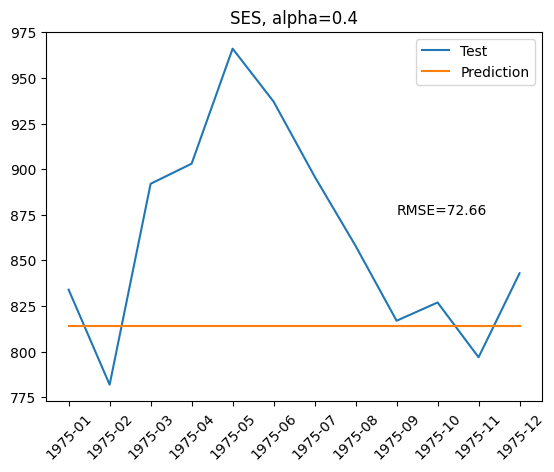

In [5]:
alpha = 0.4
ses = SimpleExpSmoothing(y_train)
fit1 = ses.fit(smoothing_level=alpha)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("SES, alpha="+str(alpha))
plt.xticks(rotation=45)
plt.legend()
plt.show()

Finding best alpha

In [7]:
alphas = np.linspace(0.01, 0.9, 100)
scores = []
for a in alphas:
    ses = SimpleExpSmoothing(y_train)
    fit1 = ses.fit(smoothing_level=a)
    y_pred = fit1.forecast(len(y_test))
    scores.append([a, root_mean_squared_error(y_test, y_pred) ])
df_scores = pd.DataFrame(scores, columns=['alpha', 'score'])

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_da

In [8]:
df_scores.sort_values('score').iloc[0]

alpha     0.090909
score    56.951670
Name: 9, dtype: float64

#### Holt's Linear Trend

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


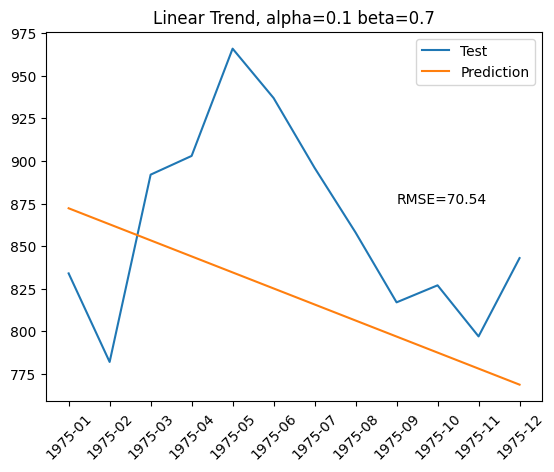

In [10]:
alpha, beta = 0.1, 0.7
holt = Holt(y_train)
fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("Linear Trend, alpha="+str(alpha)+ " beta="+str(beta))
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [11]:
alphas = np.linspace(0.01, 0.9, 20)
betas = np.linspace(0.01, 0.9, 20)
scores = []
for a in alphas:
    for b in betas:
        holt = Holt(y_train)
        fit1 = holt.fit(smoothing_level=a, smoothing_trend=b)
        y_pred = fit1.forecast(len(y_test))
        scores.append([a, b,root_mean_squared_error(y_test, y_pred) ])
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','score'])

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_da

In [12]:
df_scores.sort_values('score').iloc[0]

alpha     0.056842
beta      0.900000
score    52.799259
Name: 39, dtype: float64

#### Exponential Trend Method

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


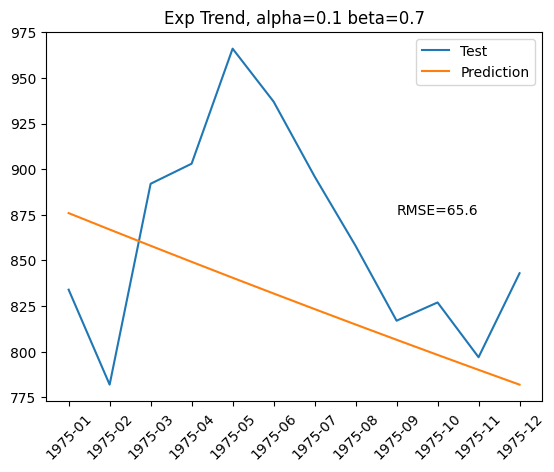

In [14]:
alpha, beta = 0.1, 0.7
holt = Holt(y_train, exponential=True)
fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("Exp Trend, alpha="+str(alpha)+ " beta="+str(beta))
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [15]:
alphas = np.linspace(0.01, 0.9, 20)
betas = np.linspace(0.01, 0.9, 20)
scores = []
for a in alphas:
    for b in betas:
        holt = Holt(y_train, exponential=True)
        fit1 = holt.fit(smoothing_level=a, smoothing_trend=b)
        y_pred = fit1.forecast(len(y_test))
        scores.append([a, b,root_mean_squared_error(y_test, y_pred) ])
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','score'])

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_da

In [16]:
df_scores.sort_values('score').iloc[0]

alpha     0.056842
beta      0.900000
score    52.998089
Name: 39, dtype: float64

#### Additive Damped Trend

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


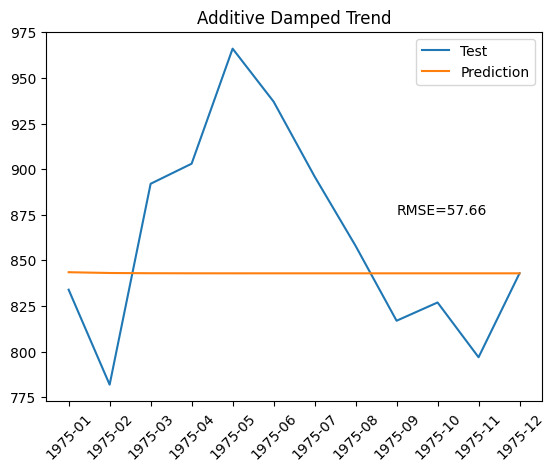

In [18]:
alpha, beta, phi = 0.1, 0.7, 0.3
holt = Holt(y_train, damped_trend=True)
fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta, damping_trend=phi)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("Additive Damped Trend")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [19]:
alphas = np.linspace(0.01, 0.9, 20)
betas = np.linspace(0.01, 0.9, 20)
phis = np.linspace(0.01, 0.9, 20)
scores = []
for a in alphas:
    for b in betas:
        for c in phis:
            holt = Holt(y_train, damped_trend=True)
            fit1 = holt.fit(smoothing_level=a, smoothing_trend=b, damping_trend=c)
            y_pred = fit1.forecast(len(y_test))
            scores.append([a, b,c,root_mean_squared_error(y_test, y_pred) ])


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_da

In [20]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','phi','score'])
df_scores.sort_values('score').iloc[0]

alpha     0.900000
beta      0.900000
phi       0.712632
score    54.643209
Name: 7995, dtype: float64

#### Holt-Winters Additive Trend

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


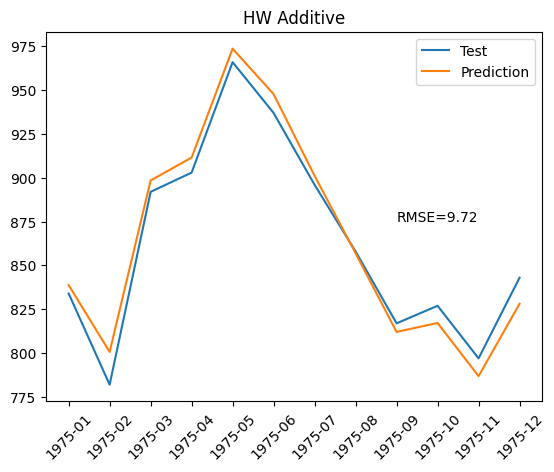

In [22]:
alpha = 0.8
beta = 0.02
gamma = 0.1
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='add')
fit1 = hw_add.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("HW Additive")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [23]:
alphas = np.linspace(0.01, 0.9, 20)
betas = np.linspace(0.01, 0.9, 20)
gammas = np.linspace(0.01, 0.9, 20)
scores = []
for a in alphas:
    for b in betas:
        for g in gammas:
            hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='add')
            fit1 = hw_add.fit(smoothing_level=a, smoothing_trend=b, smoothing_seasonal=g)
            y_pred = fit1.forecast(len(y_test))
            scores.append([a, b,g,root_mean_squared_error(y_test, y_pred) ])

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, f

In [24]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.056842
beta     0.337895
gamma    0.103684
score    6.053547
Name: 542, dtype: float64

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


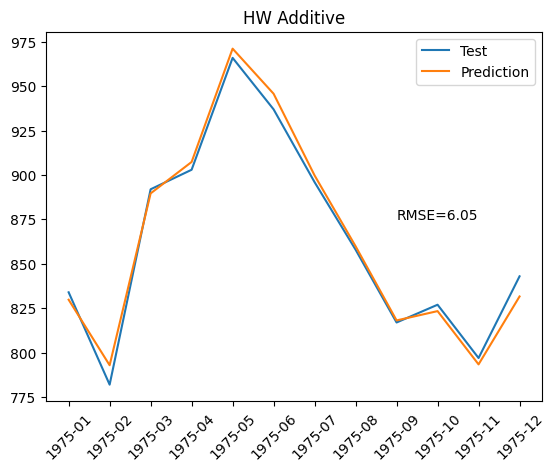

In [43]:
alpha = 0.056842
beta = 0.337895
gamma = 0.103684
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='add')
fit1 = hw_add.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("HW Additive")
plt.xticks(rotation=45)
plt.legend()
plt.show()

#### Holt-Winters Multiplicative Method

In [48]:
alphas = np.linspace(0.01, 0.9, 20)
betas = np.linspace(0.01, 0.9, 20)
gammas = np.linspace(0.01, 0.9, 20)
scores = []
for a in alphas:
    for b in betas:
        for g in gammas:
            hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='mul')
            fit1 = hw_add.fit(smoothing_level=a, smoothing_trend=b, smoothing_seasonal=g)
            y_pred = fit1.forecast(len(y_test))
            scores.append([a, b,g,root_mean_squared_error(y_test, y_pred) ])

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, f

In [50]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.665789
beta     0.010000
gamma    0.759474
score    8.258441
Name: 5616, dtype: float64